In [9]:
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

is_kaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '') != ''
ROOT_PATH = Path('/kaggle/input/waveform-inversion') if is_kaggle else Path('kaggle/input/waveform-inversion')

TRAIN_PATH = ROOT_PATH / 'train_samples'
TEST_PATH = ROOT_PATH / 'test'

# Example files

## Fault family
- Seismic data: seis_{n}_1_{i}.npy
- Velocity maps: vel_{n}_1_{i}.npy

- n represents the number of initial flat layers in velocity generation, and i is the file index.

- Seismic data seis*.npy are 4D arrays of shape (batch_size, num_sources, time_steps, num_receivers) representing wave recordings over time.
- Velocity maps vel_*.npy are 3D arrays of shape (batch_size, height, width) representing the subsurface velocity distribution.

In [16]:
n = 2
i = 0
seis = np.load(TRAIN_PATH / 'CurveFault_A' / f'seis{n}_1_{i}.npy')
vel = np.load(TRAIN_PATH / 'CurveFault_A' / f'vel{n}_1_{i}.npy').squeeze()

print("seis.shape", seis.shape)
print("vel.shape", vel.shape)

seis.shape (500, 5, 1000, 70)
vel.shape (500, 70, 70)


### Seismic data

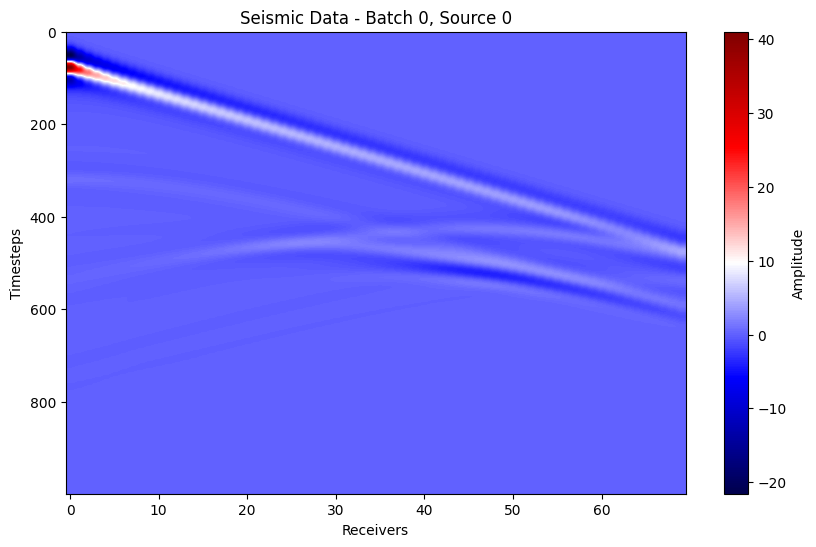

In [20]:
batch = 0
source = 0
plt.figure(figsize=(10, 6))
plt.title(f"Seismic Data - Batch {batch}, Source {source}")
plt.imshow(seis[batch, source], aspect='auto', cmap='seismic')
plt.colorbar(label="Amplitude")
plt.xlabel("Receivers")
plt.ylabel("Timesteps")
plt.show()

## Vel and Stylefamilies
- data/*.npy - Contains seismic data files in .npy format, representing recorded waveforms from receivers ). Each file contains 500 samples.
- model/*.npy - Contains velocity maps in .npy format, representing subsurface velocity distributions . Each file contains 500 samples.

In [24]:
seis = np.load(TRAIN_PATH / 'FlatVel_A' / 'data' / 'data1.npy')
vel = np.load(TRAIN_PATH / 'FlatVel_A' / 'model' / 'model1.npy').squeeze()

print("seis.shape", seis.shape)
print("vel.shape", vel.shape)

seis.shape (500, 5, 1000, 70)
vel.shape (500, 70, 70)


## Test
- what does batch_size in train_samples mean?

In [27]:
test = np.load(TEST_PATH / '000039dca2.npy')
test.shape

(5, 1000, 70)